# Alpaca EDA Examples

This notebook expands on the quickstart with practical exploratory data analysis patterns for market bars, returns, volatility, correlations, intraday behavior, crypto comparison, screeners, and account context.

Create a local `.env` from `.env.example` before running the notebook. The examples only read data through `AlpacaResearchClient`; they do not place orders.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from aic import AlpacaResearchClient

pd.options.display.float_format = "{:,.4f}".format
plt.style.use("seaborn-v0_8")

## Connect to Alpaca

`from_env()` searches for `.env` in the current directory and its parents, so this works when the kernel starts inside `notebooks/`.

In [2]:
client = AlpacaResearchClient.from_env()

## Configure an EDA Window

Use a fixed historical window for reproducible examples. Change the symbols, timeframe, or date range to explore another market slice.

In [3]:
STOCK_SYMBOLS = ["AAPL", "MSFT", "NVDA", "SPY"]
CRYPTO_SYMBOLS = ["BTC/USD", "ETH/USD"]

START = "2025-01-01"
END = None
TIMEFRAME = "1Day"

## Load and Clean Daily Stock Bars

A small preparation helper keeps timestamp handling and numeric conversion consistent across stocks, crypto, and intraday examples.

In [4]:
def prep_bars(frame: pd.DataFrame) -> pd.DataFrame:
    data = frame.copy()
    if data.empty:
        return data

    data["timestamp"] = pd.to_datetime(data["timestamp"], utc=True)
    numeric_columns = ["open", "high", "low", "close", "volume", "trade_count", "vwap"]
    for column in numeric_columns:
        if column in data.columns:
            data[column] = pd.to_numeric(data[column], errors="coerce")

    data = data.sort_values(["symbol", "timestamp"]).reset_index(drop=True)
    data["date"] = data["timestamp"].dt.date
    return data


stocks = prep_bars(
    client.stock_bars(
        STOCK_SYMBOLS,
        start=START,
        end=END,
        timeframe=TIMEFRAME,
        adjustment="all",
    )
)
stocks.head()

,symbol,timestamp,open,high,low,close,volume,trade_count,vwap,date
0,AAPL,2025-01-02 05:00:00+00:00,247.3500,247.4400,240.3100,242.2700,"1,720,928.0000","19,452.0000",242.5600,2025-01-02
1,AAPL,2025-01-03 05:00:00+00:00,241.7700,242.6100,240.3500,241.8600,"1,182,159.0000","12,869.0000",241.4400,2025-01-03
2,AAPL,2025-01-06 05:00:00+00:00,242.7600,245.7600,242.3300,243.4700,"970,622.0000","13,645.0000",243.8000,2025-01-06
3,AAPL,2025-01-07 05:00:00+00:00,241.2300,243.9700,239.8500,240.7200,"1,048,220.0000","12,788.0000",241.8200,2025-01-07
4,AAPL,2025-01-08 05:00:00+00:00,240.4300,242.1200,238.6400,241.0900,"868,980.0000","12,123.0000",240.5200,2025-01-08


## Inspect Schema and Missingness

Start every EDA pass with the shape, dtypes, missingness, and unique counts. These checks catch symbol coverage issues before downstream charts become misleading.

In [5]:
schema_profile = pd.DataFrame(
    {
        "dtype": stocks.dtypes.astype(str),
        "missing": stocks.isna().sum(),
        "missing_pct": stocks.isna().mean().mul(100).round(2),
        "unique": stocks.nunique(dropna=True),
    }
).sort_index()

schema_profile

,dtype,missing,missing_pct,unique
close,float64,0,0.0000,1435
date,object,0,0.0000,368
high,float64,0,0.0000,1437
low,float64,0,0.0000,1440
open,float64,0,0.0000,1448
symbol,str,0,0.0000,4
timestamp,"datetime64[us, UTC]",0,0.0000,368
trade_count,float64,0,0.0000,1441
volume,float64,0,0.0000,1472
vwap,float64,0,0.0000,1452


In [6]:
coverage = (
    stocks.groupby("symbol")
    .agg(
        first_timestamp=("timestamp", "min"),
        last_timestamp=("timestamp", "max"),
        rows=("close", "size"),
        avg_volume=("volume", "mean"),
        min_close=("close", "min"),
        max_close=("close", "max"),
    )
    .sort_values("rows", ascending=False)
)

coverage

,first_timestamp,last_timestamp,rows,avg_volume,min_close,max_close
symbol,,,,,,
AAPL,2025-01-02 05:00:00+00:00,2026-06-23 04:00:00+00:00,368,"1,449,001.3804",171.8900,315.1950
MSFT,2025-01-02 05:00:00+00:00,2026-06-23 04:00:00+00:00,368,"677,566.6603",351.9500,539.0100
NVDA,2025-01-02 05:00:00+00:00,2026-06-23 04:00:00+00:00,368,"3,867,038.9103",94.1500,235.5100
SPY,2025-01-02 05:00:00+00:00,2026-06-23 04:00:00+00:00,368,"1,335,790.8967",489.6900,757.5200


## Build Price, Volume, and Return Panels

Wide panels make cross-asset analysis easier: one timestamp index, one column per symbol.

In [7]:
price_panel = stocks.pivot(index="timestamp", columns="symbol", values="close").sort_index()
volume_panel = stocks.pivot(index="timestamp", columns="symbol", values="volume").sort_index()

daily_returns = price_panel.pct_change(fill_method=None).dropna(how="all")
log_returns = np.log(price_panel).diff().dropna(how="all")

price_panel.tail()

symbol,AAPL,MSFT,NVDA,SPY
timestamp,,,,
2026-06-16 04:00:00+00:00,299.2600,393.9700,207.3700,748.6500
2026-06-17 04:00:00+00:00,296.0700,379.0500,204.7000,739.1200
2026-06-18 04:00:00+00:00,297.8600,379.0800,210.3800,746.7500
2026-06-22 04:00:00+00:00,296.8500,367.2100,208.5900,744.2700
2026-06-23 04:00:00+00:00,294.2800,373.9300,200.0700,733.6200


In [8]:
return_summary = daily_returns.agg(["mean", "std", "min", "max"]).T
return_summary["annualized_return"] = (1 + daily_returns.mean()) ** 252 - 1
return_summary["annualized_volatility"] = daily_returns.std() * np.sqrt(252)
return_summary["sharpe_0rf"] = (
    return_summary["annualized_return"] / return_summary["annualized_volatility"]
)

return_summary.sort_values("annualized_return", ascending=False)

,mean,std,min,max,annualized_return,annualized_volatility,sharpe_0rf
symbol,,,,,,,
NVDA,0.0014,0.0291,-0.1690,0.1846,0.4349,0.4618,0.9417
SPY,0.0007,0.0109,-0.0584,0.0933,0.2000,0.1727,1.1584
AAPL,0.0007,0.0187,-0.0929,0.1485,0.1940,0.2976,0.6518
MSFT,-0.0001,0.0173,-0.1007,0.0970,-0.0314,0.2741,-0.1145


## Cumulative Returns and Drawdowns

Cumulative returns show growth from the start date. Drawdowns show peak-to-trough damage along the way.

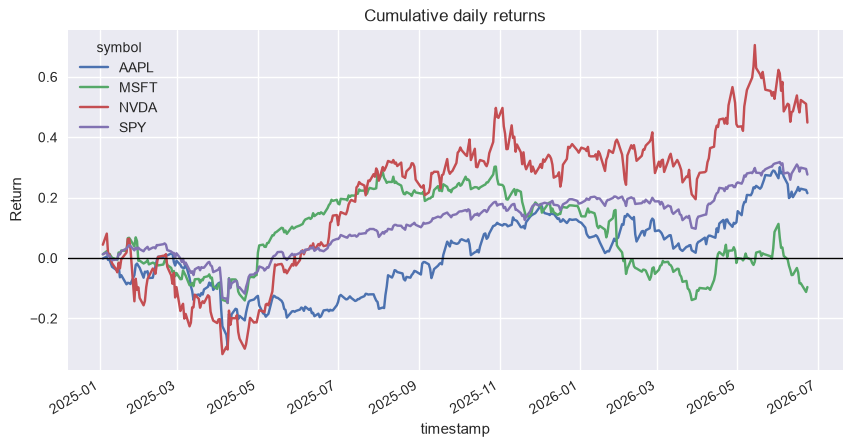

In [9]:
cumulative_returns = (1 + daily_returns.fillna(0)).cumprod().sub(1)

ax = cumulative_returns.plot(figsize=(10, 5), title="Cumulative daily returns")
ax.axhline(0, color="black", linewidth=1)
ax.set_ylabel("Return")
plt.show()

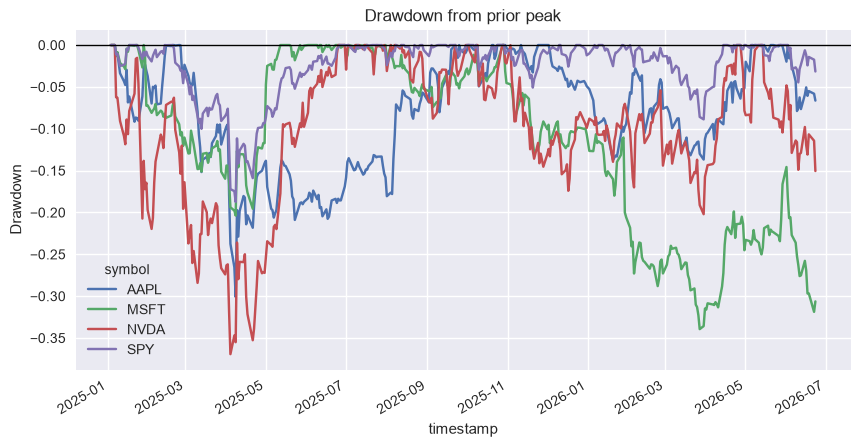

,max_drawdown
symbol,
NVDA,-0.3693
MSFT,-0.3394
AAPL,-0.3010
SPY,-0.1874


In [10]:
wealth_index = (1 + daily_returns.fillna(0)).cumprod()
drawdown = wealth_index.div(wealth_index.cummax()).sub(1)
max_drawdown = drawdown.min().sort_values()

ax = drawdown.plot(figsize=(10, 5), title="Drawdown from prior peak")
ax.axhline(0, color="black", linewidth=1)
ax.set_ylabel("Drawdown")
plt.show()

max_drawdown.to_frame("max_drawdown")

## Rolling Behavior

Rolling averages and volatility help separate short-term noise from persistent shifts.

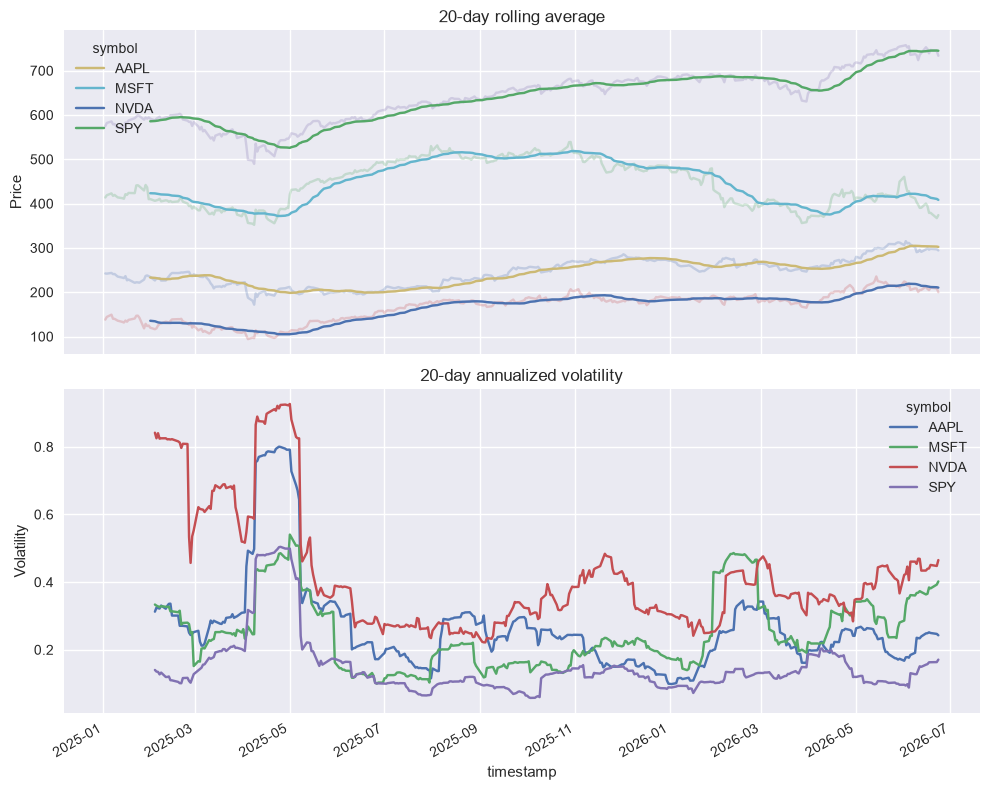

In [11]:
ROLLING_WINDOW = 20

rolling_mean = price_panel.rolling(ROLLING_WINDOW).mean()
rolling_volatility = daily_returns.rolling(ROLLING_WINDOW).std() * np.sqrt(252)

fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True)
price_panel.plot(ax=axes[0], alpha=0.25, legend=False)
rolling_mean.plot(ax=axes[0])
axes[0].set_title(f"{ROLLING_WINDOW}-day rolling average")
axes[0].set_ylabel("Price")

rolling_volatility.plot(ax=axes[1])
axes[1].set_title(f"{ROLLING_WINDOW}-day annualized volatility")
axes[1].set_ylabel("Volatility")

fig.tight_layout()
plt.show()

## Correlation Heatmap

Correlations are regime-dependent, but a first look helps identify redundant exposures.

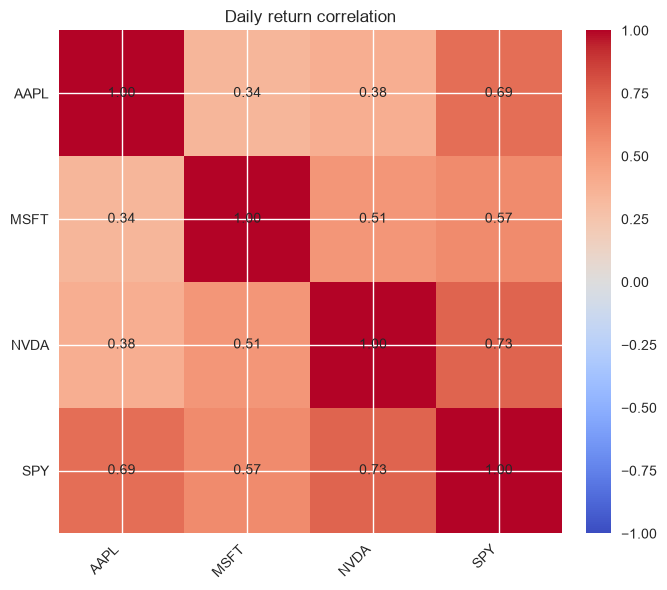

symbol,AAPL,MSFT,NVDA,SPY
symbol,,,,
AAPL,1.0000,0.3387,0.3832,0.6915
MSFT,0.3387,1.0000,0.5136,0.5673
NVDA,0.3832,0.5136,1.0000,0.7295
SPY,0.6915,0.5673,0.7295,1.0000


In [12]:
correlation = daily_returns.corr()

fig, ax = plt.subplots(figsize=(7, 6))
image = ax.imshow(correlation, vmin=-1, vmax=1, cmap="coolwarm")
ax.set_xticks(range(len(correlation.columns)), labels=correlation.columns, rotation=45, ha="right")
ax.set_yticks(range(len(correlation.index)), labels=correlation.index)
ax.set_title("Daily return correlation")

for row_idx, row_label in enumerate(correlation.index):
    for col_idx, col_label in enumerate(correlation.columns):
        ax.text(col_idx, row_idx, f"{correlation.loc[row_label, col_label]:.2f}", ha="center", va="center")

fig.colorbar(image, ax=ax, fraction=0.046, pad=0.04)
fig.tight_layout()
plt.show()

correlation

## Equal-Weight Portfolio Sketch

A quick benchmark-style view can reveal whether a basket behaves differently from a broad market ETF.

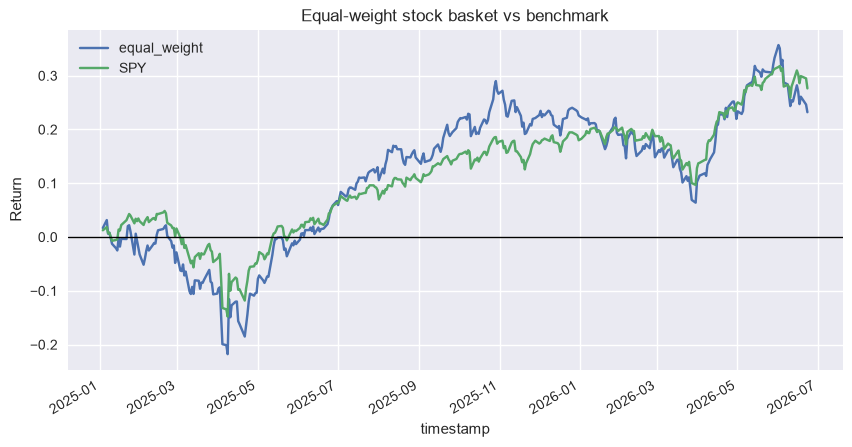

,count,mean,std,min,25%,50%,75%,max
equal_weight,367.0000,0.0007,0.0153,-0.0605,-0.0061,0.0014,0.0087,0.1309
SPY,367.0000,0.0007,0.0109,-0.0584,-0.0035,0.0012,0.0059,0.0933


In [13]:
portfolio_returns = pd.DataFrame(
    {"equal_weight": daily_returns.reindex(columns=STOCK_SYMBOLS).mean(axis=1)}
)
if "SPY" in daily_returns.columns:
    portfolio_returns["SPY"] = daily_returns["SPY"]

portfolio_growth = (1 + portfolio_returns.fillna(0)).cumprod().sub(1)
ax = portfolio_growth.plot(figsize=(10, 5), title="Equal-weight stock basket vs benchmark")
ax.axhline(0, color="black", linewidth=1)
ax.set_ylabel("Return")
plt.show()

portfolio_returns.describe().T

## Intraday Seasonality Example

Intraday bars make it possible to inspect time-of-day volume and price behavior. Keep the date range narrow so the request stays quick.

In [14]:
INTRADAY_SYMBOLS = ["AAPL", "MSFT"]
INTRADAY_START = "2025-04-01"
INTRADAY_END = "2025-04-15"

intraday = prep_bars(
    client.stock_bars(
        INTRADAY_SYMBOLS,
        start=INTRADAY_START,
        end=INTRADAY_END,
        timeframe="15Min",
        adjustment="all",
        limit=10_000,
    )
)

intraday["market_time"] = intraday["timestamp"].dt.tz_convert("America/New_York")
intraday["session"] = intraday["market_time"].dt.date
intraday["bar_time"] = intraday["market_time"].dt.strftime("%H:%M")
intraday["bar_return"] = intraday.groupby("symbol")["close"].pct_change(fill_method=None)

intraday.head()

,symbol,timestamp,open,high,low,close,volume,trade_count,vwap,date,market_time,session,bar_time,bar_return
0,AAPL,2025-04-01 13:00:00+00:00,219.0900,219.4300,219.0900,219.4300,772.0000,7.0000,219.2027,2025-04-01,2025-04-01 09:00:00-04:00,2025-04-01,09:00,NaN
1,AAPL,2025-04-01 13:15:00+00:00,219.2200,219.2300,219.2200,219.2300,500.0000,8.0000,219.2200,2025-04-01,2025-04-01 09:15:00-04:00,2025-04-01,09:15,-0.0009
2,AAPL,2025-04-01 13:30:00+00:00,218.5900,220.1000,217.7600,219.8900,"153,706.0000","1,651.0000",218.8296,2025-04-01,2025-04-01 09:30:00-04:00,2025-04-01,09:30,0.0030
3,AAPL,2025-04-01 13:45:00+00:00,219.8100,222.1600,219.7900,221.9600,"100,577.0000","1,359.0000",221.3140,2025-04-01,2025-04-01 09:45:00-04:00,2025-04-01,09:45,0.0094
4,AAPL,2025-04-01 14:00:00+00:00,221.9000,222.1800,220.1100,220.4300,"90,684.0000","1,229.0000",221.2124,2025-04-01,2025-04-01 10:00:00-04:00,2025-04-01,10:00,-0.0069


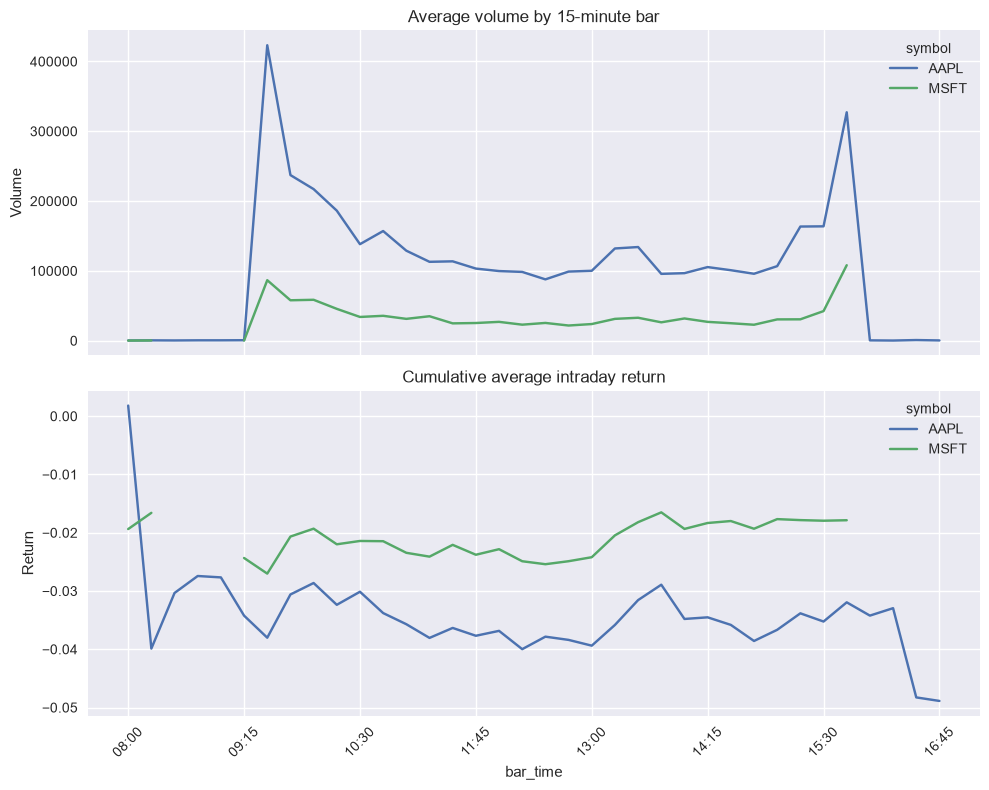

In [15]:
volume_by_time = intraday.pivot_table(
    index="bar_time", columns="symbol", values="volume", aggfunc="mean"
)
return_by_time = intraday.pivot_table(
    index="bar_time", columns="symbol", values="bar_return", aggfunc="mean"
)

fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True)
volume_by_time.plot(ax=axes[0], title="Average volume by 15-minute bar")
axes[0].set_ylabel("Volume")

return_by_time.cumsum().plot(ax=axes[1], title="Cumulative average intraday return")
axes[1].set_ylabel("Return")
axes[1].tick_params(axis="x", rotation=45)

fig.tight_layout()
plt.show()

## Crypto Comparison

Crypto trades continuously, so compare it with equities carefully. The shared date index below keeps the first pass simple.

In [16]:
crypto = prep_bars(
    client.crypto_bars(
        CRYPTO_SYMBOLS,
        start=START,
        end=END,
        timeframe=TIMEFRAME,
    )
)

crypto_prices = crypto.pivot(index="timestamp", columns="symbol", values="close").sort_index()
crypto_returns = crypto_prices.pct_change(fill_method=None).dropna(how="all")

crypto.head()

,symbol,timestamp,open,high,low,close,volume,trade_count,vwap,date
0,BTC/USD,2025-01-01 00:00:00+00:00,"93,381.5825","94,976.9360","92,772.2000","94,455.2870",0.4846,106.0000,"94,126.5048",2025-01-01
1,BTC/USD,2025-01-02 00:00:00+00:00,"94,372.4310","97,784.1708","94,222.2500","96,828.8300",2.6806,275.0000,"96,435.4323",2025-01-02
2,BTC/USD,2025-01-03 00:00:00+00:00,"96,921.7555","98,946.1865","96,028.5150","98,094.4230",3.8500,271.0000,"97,387.2710",2025-01-03
3,BTC/USD,2025-01-04 00:00:00+00:00,"98,184.2500","98,744.4620","97,551.2350","98,288.3780",0.8121,146.0000,"98,168.1313",2025-01-04
4,BTC/USD,2025-01-05 00:00:00+00:00,"98,256.7000","98,779.7655","97,296.4857","98,322.4200",1.8306,129.0000,"98,098.1386",2025-01-05


/var/folders/98/pwg5d4bn50107_sbmtz08_wr0000gn/T/ipykernel_12367/1343658558.py:1: Pandas4Warning: Sorting by default when concatenating all DatetimeIndex is deprecated.  In the future, pandas will respect the default of `sort=False`. Specify `sort=True` or `sort=False` to silence this message. If you see this warnings when not directly calling concat, report a bug to pandas.
  all_returns = pd.concat([daily_returns, crypto_returns], axis=1).dropna(how="all")


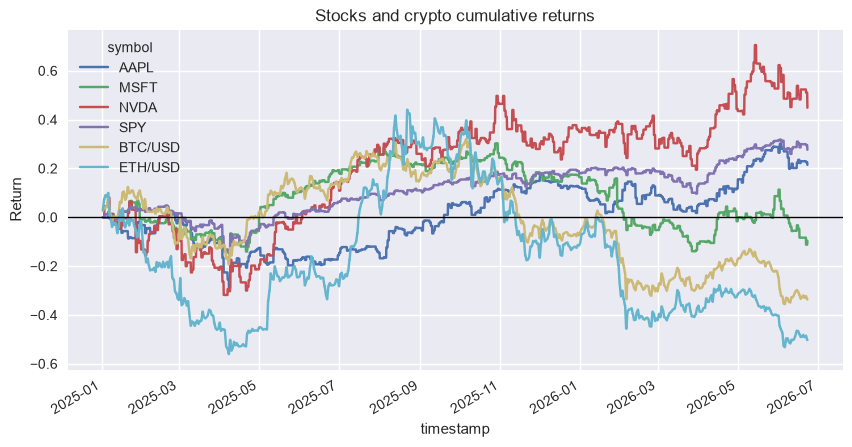

symbol,AAPL,MSFT,NVDA,SPY,BTC/USD,ETH/USD
symbol,,,,,,
AAPL,1.0000,0.3387,0.3832,0.6915,NaN,NaN
MSFT,0.3387,1.0000,0.5136,0.5673,NaN,NaN
NVDA,0.3832,0.5136,1.0000,0.7295,NaN,NaN
SPY,0.6915,0.5673,0.7295,1.0000,NaN,NaN
BTC/USD,NaN,NaN,NaN,NaN,1.0000,0.8439
ETH/USD,NaN,NaN,NaN,NaN,0.8439,1.0000


In [17]:
all_returns = pd.concat([daily_returns, crypto_returns], axis=1).dropna(how="all")
all_cumulative_returns = (1 + all_returns.fillna(0)).cumprod().sub(1)

ax = all_cumulative_returns.plot(figsize=(10, 5), title="Stocks and crypto cumulative returns")
ax.axhline(0, color="black", linewidth=1)
ax.set_ylabel("Return")
plt.show()

all_returns.corr()

## Screener Context

Screeners are useful for quickly finding symbols worth a deeper follow-up EDA pass.

In [18]:
most_active = client.most_actives(top=10)
market_movers = client.market_movers(top=10)

display(most_active)
display(market_movers)

,symbol,volume,trade_count,last_updated
0,ADTX,"4,402,560,058.0000","792,415.0000",2026-06-23T22:11:00.130199Z
1,SOXS,"873,480,832.0000","514,057.0000",2026-06-23T22:11:00.130199Z
2,ATLN,"419,830,307.0000","890,176.0000",2026-06-23T22:11:00.130199Z
3,TZA,"324,541,495.0000","101,785.0000",2026-06-23T22:11:00.130199Z
4,INLF,"305,681,582.0000","177,911.0000",2026-06-23T22:11:00.130199Z
5,MGN,"211,026,536.0000","169,064.0000",2026-06-23T22:11:00.130199Z
6,AAL,"166,431,875.0000","174,817.0000",2026-06-23T22:11:00.130199Z
7,CIIT,"157,590,185.0000","388,764.0000",2026-06-23T22:11:00.130199Z
8,SPCX,"156,154,724.0000","2,869,102.0000",2026-06-23T22:11:00.130199Z
9,NVDA,"154,095,860.0000","2,591,612.0000",2026-06-23T22:11:00.130199Z


,section,symbol,percent_change,change,price,market_type,last_updated
0,gainers,ATLN,202.4100,0.8902,1.3300,stocks,2026-06-23T22:11:00.130199Z
1,gainers,TBLAW,140.0000,0.0028,0.0048,stocks,2026-06-23T22:11:00.130199Z
2,gainers,SBFMW,123.6300,0.0497,0.0899,stocks,2026-06-23T22:11:00.130199Z
3,gainers,ADTX,117.1900,0.0225,0.0417,stocks,2026-06-23T22:11:00.130199Z
4,gainers,ILLRW,113.5100,0.0126,0.0237,stocks,2026-06-23T22:11:00.130199Z
5,gainers,FCUV,89.2300,1.9380,4.1100,stocks,2026-06-23T22:11:00.130199Z
6,gainers,BOLD,85.7100,1.2000,2.6000,stocks,2026-06-23T22:11:00.130199Z
7,gainers,WLDSW,85.5600,6.3400,13.7500,stocks,2026-06-23T22:11:00.130199Z
8,gainers,CIIT,81.1800,0.3978,0.8878,stocks,2026-06-23T22:11:00.130199Z
9,gainers,RCKTW,79.0700,0.0034,0.0077,stocks,2026-06-23T22:11:00.130199Z


## Account and Position Context

Paper account data can add useful portfolio context to market EDA. This section stays read-only.

In [19]:
account = client.account()
account_columns = ["status", "currency", "buying_power", "cash", "portfolio_value"]
account.reindex(columns=[column for column in account_columns if column in account.columns])

,status,currency,buying_power,cash,portfolio_value
0,ACTIVE,USD,377332.73,87269.11,99849.12


In [20]:
positions = client.positions()
positions_summary = positions.copy()

for column in ["qty", "market_value", "cost_basis", "unrealized_pl", "unrealized_plpc"]:
    if column in positions_summary.columns:
        positions_summary[column] = pd.to_numeric(positions_summary[column], errors="coerce")

if "market_value" in positions_summary.columns:
    positions_summary = positions_summary.sort_values("market_value", ascending=False)

positions_summary.head(20)

,asset_id,symbol,exchange,asset_class,asset_marginable,avg_entry_price,qty,side,market_value,cost_basis,...,unrealized_plpc,unrealized_intraday_pl,unrealized_intraday_plpc,current_price,lastday_price,change_today,swap_rate,avg_entry_swap_rate,usd,qty_available
0,b0b6dd9d-8b9b-48a9-ba46-b9d54906e415,AAPL,NASDAQ,us_equity,True,296.352929,31.3814,long,"9,241.8125","9,299.9600",...,-0.0063,-78.767231,-0.00845,294.5,297.01,-0.00845,None,None,None,31.381366885
3,64bbff51-59d6-4b3c-9351-13ad85e3c752,BTCUSD,CRYPTO,crypto,False,64108.295882182,0.0397,long,"2,488.4770","2,546.3636",...,-0.0227,-57.081607,-0.02242,62650.92,64088.03,-0.02242,None,None,None,0.03971972
2,798c7614-54a3-4512-8213-9aa1273e4e3e,BTC,ARCA,us_equity,True,28.417667,30.0000,long,829.5000,852.5300,...,-0.0270,-24.9,-0.02914,27.65,28.48,-0.02914,None,None,None,30
1,f801f835-bfe6-4a9d-a6b1-ccbb84bfd75f,AMZN,NASDAQ,us_equity,True,240.31,0.1000,long,23.3590,24.0310,...,-0.0280,0.08,0.00344,233.59,232.79,0.00344,None,None,None,0.1


## Feature Table for Follow-up Analysis

EDA often ends with a tidy feature table that can feed a hypothesis test, dashboard, or model experiment.

In [21]:
features = stocks.copy()
features["return_1d"] = features.groupby("symbol")["close"].pct_change(fill_method=None)
features["dollar_volume"] = features["close"] * features["volume"]
features["range_pct"] = (features["high"] - features["low"]) / features["close"]
features["rolling_return_5d"] = features.groupby("symbol")["return_1d"].transform(
    lambda series: series.rolling(5).mean()
)
features["rolling_vol_20d"] = features.groupby("symbol")["return_1d"].transform(
    lambda series: series.rolling(20).std() * np.sqrt(252)
)
features["volume_zscore_20d"] = features.groupby("symbol")["volume"].transform(
    lambda series: (series - series.rolling(20).mean()) / series.rolling(20).std()
)

features.dropna(subset=["return_1d"]).tail(20)

,symbol,timestamp,open,high,low,close,volume,trade_count,vwap,date,return_1d,dollar_volume,range_pct,rolling_return_5d,rolling_vol_20d,volume_zscore_20d
1452,SPY,2026-05-26 04:00:00+00:00,748.2100,750.1800,746.4500,748.5300,"1,273,804.0000","22,543.0000",748.0900,2026-05-26,0.0064,"953,480,508.1200",0.0050,0.0033,0.1028,-0.2479
1453,SPY,2026-05-27 04:00:00+00:00,748.9600,749.4200,746.3300,748.6600,"1,326,701.0000","22,731.0000",748.1900,2026-05-27,0.0002,"993,247,970.6600",0.0041,0.0045,0.0996,-0.0676
1454,SPY,2026-05-28 04:00:00+00:00,748.3000,753.2000,747.3300,752.7400,"1,218,138.0000","21,273.0000",751.6400,2026-05-28,0.0054,"916,941,198.1200",0.0078,0.0036,0.0995,-0.5873
1455,SPY,2026-05-29 04:00:00+00:00,753.9200,756.1100,752.7800,754.4000,"1,674,069.0000","30,061.0000",754.6600,2026-05-29,0.0022,"1,262,917,653.6000",0.0044,0.0036,0.0964,1.5640
1456,SPY,2026-06-01 04:00:00+00:00,753.6200,758.3100,752.8000,756.4900,"1,446,621.0000","24,204.0000",755.6000,2026-06-01,0.0028,"1,094,354,320.2900",0.0073,0.0034,0.0963,0.4777
1457,SPY,2026-06-02 04:00:00+00:00,755.2600,758.4500,754.8100,757.5200,"1,164,371.0000","20,441.0000",757.0400,2026-06-02,0.0014,"882,034,319.9200",0.0048,0.0024,0.0939,-0.9073
1458,SPY,2026-06-03 04:00:00+00:00,756.2500,756.8400,751.6500,752.2400,"1,906,675.0000","29,308.0000",753.4700,2026-06-03,-0.0070,"1,434,277,202.0000",0.0069,0.0010,0.0981,2.1966
1459,SPY,2026-06-04 04:00:00+00:00,750.1300,756.3500,749.5400,755.0300,"1,546,700.0000","26,881.0000",754.1200,2026-06-04,0.0037,"1,167,804,901.0000",0.0090,0.0006,0.0880,0.7750
1460,SPY,2026-06-05 04:00:00+00:00,750.3600,750.8700,733.7000,735.5600,"2,829,329.0000","46,592.0000",741.2300,2026-06-05,-0.0258,"2,081,141,239.2400",0.0233,-0.0050,0.1305,3.4932
1461,SPY,2026-06-08 04:00:00+00:00,741.4400,743.4100,736.3000,737.3400,"1,709,067.0000","29,762.0000",739.7700,2026-06-08,0.0024,"1,260,163,461.7800",0.0096,-0.0051,0.1275,0.6139


In [22]:
eda_summary = {
    "stock_rows": len(stocks),
    "stock_symbols": sorted(stocks["symbol"].unique().tolist()),
    "first_stock_timestamp": stocks["timestamp"].min(),
    "last_stock_timestamp": stocks["timestamp"].max(),
    "crypto_rows": len(crypto),
    "crypto_symbols": sorted(crypto["symbol"].unique().tolist()),
    "feature_columns": features.columns.tolist(),
}

eda_summary

{'stock_rows': 1472,
 'stock_symbols': ['AAPL', 'MSFT', 'NVDA', 'SPY'],
 'first_stock_timestamp': Timestamp('2025-01-02 05:00:00+0000', tz='UTC'),
 'last_stock_timestamp': Timestamp('2026-06-23 04:00:00+0000', tz='UTC'),
 'crypto_rows': 1078,
 'crypto_symbols': ['BTC/USD', 'ETH/USD'],
 'feature_columns': ['symbol',
  'timestamp',
  'open',
  'high',
  'low',
  'close',
  'volume',
  'trade_count',
  'vwap',
  'date',
  'return_1d',
  'dollar_volume',
  'range_pct',
  'rolling_return_5d',
  'rolling_vol_20d',
  'volume_zscore_20d']}